### Auto-Encoder and VAE

Este es un primer intento básico de un Auto-Encoder y un VAE

In [1]:
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

Descargamos los datos, para esta primer prueba dividimos solo en train y test

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='/Users/miguelpamanes/Library/Mobile Documents/com~apple~CloudDocs/GSoC/data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='/Users/miguelpamanes/Library/Mobile Documents/com~apple~CloudDocs/GSoC/data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [3]:
def ejemplo_imagenes(images, labels):

    fig, axs = plt.subplots(ncols=len(images), nrows=1, figsize=(12,5))

    for i in range(len(images)):

        axs[i].imshow(images[i], cmap='gray')
        axs[i].set_title(f'Label: {labels[i]}')

        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_xlabel(f'Index: {i}')
    
    
    plt.tight_layout()
    plt.show()

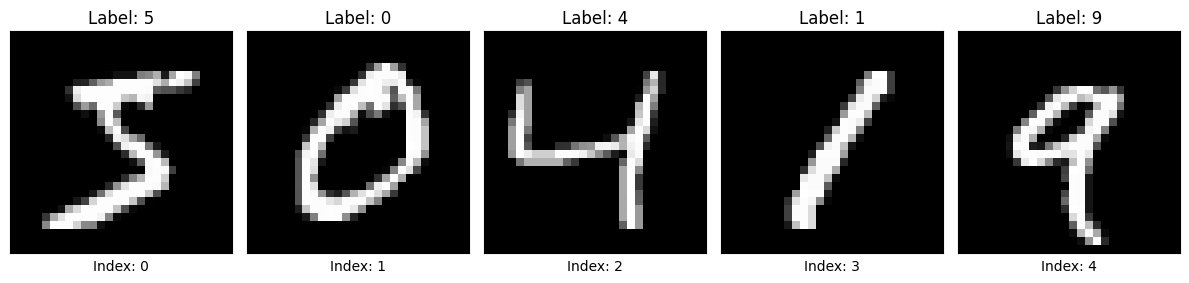

In [4]:
imagenes_ejemplo = np.stack([train_dataset[i][0].squeeze().numpy() for i in range(5)])

etiquetas_ejemplo = [train_dataset[i][1] for i in range(5)]

ejemplo_imagenes(imagenes_ejemplo, etiquetas_ejemplo)

Generamos el Auto-Encoder

Para este primer ejemplo usamos capas lineales y relu.
Trabajamos con capas lineales ya que convertimos nuestros datos al inicio a tensores (dim 28 x 28)

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.num_hidden = 8

        #Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, self.num_hidden),
            nn.ReLU()
        )

        #Decoder
        self.decoder = nn.Sequential(
            nn.Linear(self.num_hidden, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded

Aplicamos los parametros

La funcción de pérdida será solo MSE

In [6]:
learning_rate = 1e-4
batch_size = 64

model1 = AutoEncoder()
optimizer = optim.Adam(model1.parameters(), lr= learning_rate)
m_s_e = nn.MSELoss()

device = "cuda" if torch.cuda.is_available() else "cpu"

model1.to(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

Entrenamos el modelo por 10 épocas

In [7]:
num_epochs = 10
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.view(images.size(0), -1)
        images = images.to(device)

        encoded, decoded = model1(images)

        loss = m_s_e(decoded, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()*images.size(0)

    epoch_loss = total_loss / len(train_loader.dataset)

    print(f'Epoch: {epoch + 1}/{num_epochs} | loss={epoch_loss:.4f}')


Epoch: 1/10 | loss=0.0729
Epoch: 2/10 | loss=0.0506
Epoch: 3/10 | loss=0.0477
Epoch: 4/10 | loss=0.0460
Epoch: 5/10 | loss=0.0448
Epoch: 6/10 | loss=0.0438
Epoch: 7/10 | loss=0.0430
Epoch: 8/10 | loss=0.0424
Epoch: 9/10 | loss=0.0418
Epoch: 10/10 | loss=0.0399


Visualizamos algunos ejemplos

In [8]:
n = 5

with torch.no_grad():

    images, labels = next(iter(test_loader))
    images = images[:n]
    images_flat = images.view(images.size(0), -1).to(device)

    encoded, reconstructed = model1(images_flat)

images_np = images.cpu().numpy()
reconstructed_np = reconstructed.cpu().numpy()

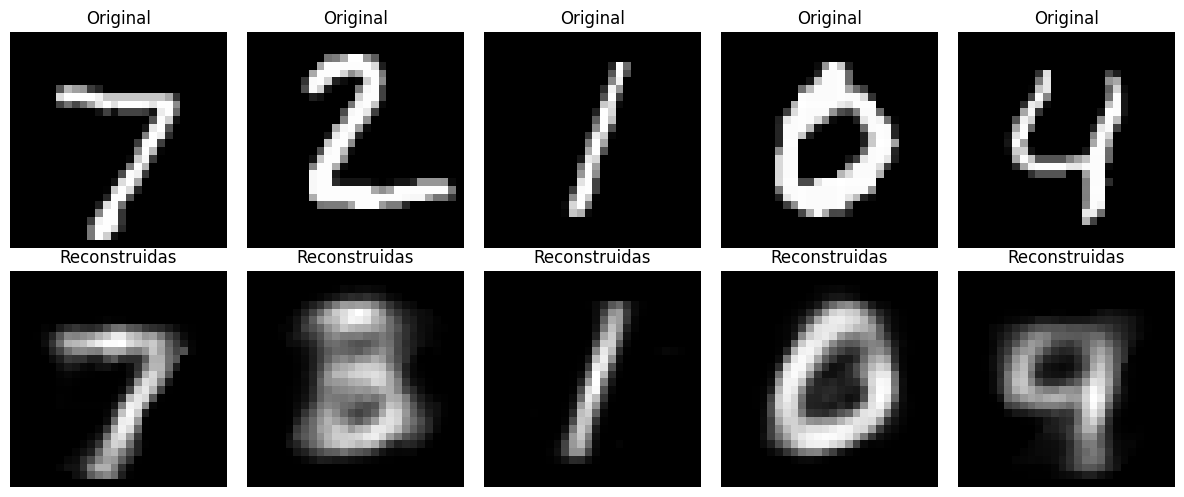

In [9]:
n = 5

fig, axes = plt.subplots(2, n, figsize=(12,5))

for i in range(n):

    axes[0, i].imshow(images_np[i].reshape(28,28), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(reconstructed_np[i].reshape(28,28), cmap='gray')
    axes[1, i].set_title("Reconstruidas")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Generamos el Variational Auto-Encoder. Para este primer ejercicio heredamos el auto encoder realizado anteriormente.

Usamos un espacio latente de 8 dimensiones.

Usamos el truco de parametrización.

In [10]:
class VAE(AutoEncoder):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU()
        )

        self.mu = nn.Linear(256, self.num_hidden)
        self.log_var = nn.Linear(256, self.num_hidden)

    def reparametrizacion(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return mu+eps*std
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        mu = self.mu(encoded)
        log_var = self.log_var(encoded)

        z = self.reparametrizacion(mu, log_var)
        decoded = self.decoder(z)

        return encoded, decoded, mu, log_var
    
    def sample(self, num_samples):

        current_device = next(self.parameters()).device

        with torch.no_grad():
            z = torch.randn(num_samples, self.num_hidden).to(current_device)
            samples = self.decoder(z)

        return(samples)
        

Calculamos la función de pérdida

La función que se minimiza es el negativo del ELBO (*Evidence Lower Bound*):

$$\mathcal{L} = -\mathbb{E}_{q(z|x)} \left[ \log p(x|z) \right] + D_{\mathrm{KL}} \bigl( q(z|x)\,\|\,p(z) \bigr) $$

donde:

- $\mathbb{E}_{q(z|x)}[\log p(x|z)]$ es el término de reconstrucción. Correspondiente al BCE para distribucion [0,1]
- $D_{\mathrm{KL}}(q(z|x)\|p(z))$ es la divergencia de Kullback-Leibler. Que tiene la forma: 
$$ D_{KL} = \frac{1}{2} \sum_j \left( \mu_j^2 + \sigma_j^2 - \log(\sigma_j^2) - 1 \right) $$
- $q(z|x)$ es la distribución aprendida por el encoder.
- $p(z)=\mathcal{N}(0,1)$ es el prior gaussiano estándar.


In [11]:
def loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1,784), reduction='sum')
    KLD = - 0.5 *torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return BCE + KLD

Definimos el entrenamiento

In [12]:
def train_VAE(dataset, learning_rate, num_epochs, batch_size):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model = VAE()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_idx, (images, labels) in enumerate(train_loader):

            images = images.to(device)
            
            encoded, decoded, mu, log_var = model(images)

            loss = loss_function(decoded, images, mu, log_var)            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss/len(train_loader.dataset)
        print(f'Epoch: {epoch +1}/{num_epochs} | Loss = {epoch_loss:.4f}')

    return model
        

Entrenamos el modelo por 10 épocas

In [13]:
model2 = train_VAE(dataset = train_dataset, learning_rate=1e-3, num_epochs=10, batch_size=128)

Epoch: 1/10 | Loss = 171.6069
Epoch: 2/10 | Loss = 131.1274
Epoch: 3/10 | Loss = 125.7290
Epoch: 4/10 | Loss = 122.9591
Epoch: 5/10 | Loss = 121.1650
Epoch: 6/10 | Loss = 119.8847
Epoch: 7/10 | Loss = 118.8870
Epoch: 8/10 | Loss = 118.0610
Epoch: 9/10 | Loss = 117.3412
Epoch: 10/10 | Loss = 116.7190


In [14]:
import matplotlib.pyplot as plt
import torch

def ver_reconstrucciones(model, dataset, num_images=5, device='cpu'):
    model.eval()
    images = []
    for i in range(num_images):
        img, label = dataset[i]
        images.append(img)
        
    images = torch.stack(images).to(device)
    
    with torch.no_grad():
        encoded, decoded, mu, log_var = model(images)
        
    images = images.cpu()
    decoded = decoded.cpu()
    
    fig, axes = plt.subplots(2, num_images, figsize=(12,5))
    
    for i in range(num_images):
        ax_orig = axes[0, i]
        ax_orig.imshow(images[i].squeeze(), cmap='gray')
        ax_orig.axis('off')
        ax_orig.set_title('Originales')
            
        ax_recon = axes[1, i]
        ax_recon.imshow(decoded[i].view(28, 28), cmap='gray')
        ax_recon.axis('off')
        ax_recon.set_title('Reconstruidas')
            
    plt.tight_layout()
    plt.show()

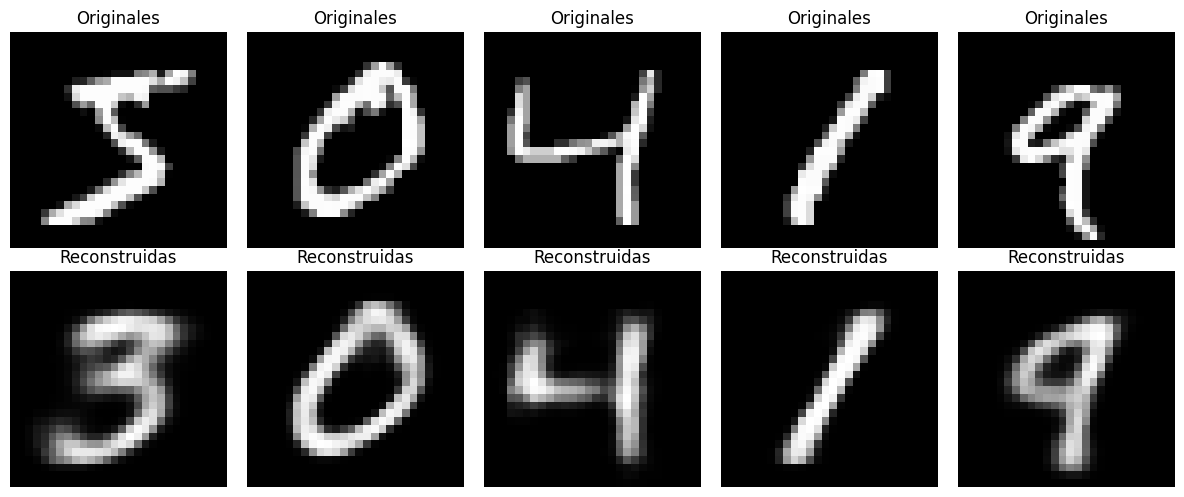

In [15]:
ver_reconstrucciones(model2, train_dataset, num_images=5, device='cpu')